In [1]:
from api_dados import coletar_dados

import pandas as pd
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# --- dados ---
nome_produto = 'dados-hidrologicos-res'
df = coletar_dados('ons', nome_produto)

# ate 31/01/2026 para reprodutibilidade
df['din_instante'] = pd.to_datetime(df['din_instante'])
df = df[df['din_instante'] <= '2026-01-31']

Iniciando download de 27 arquivos...


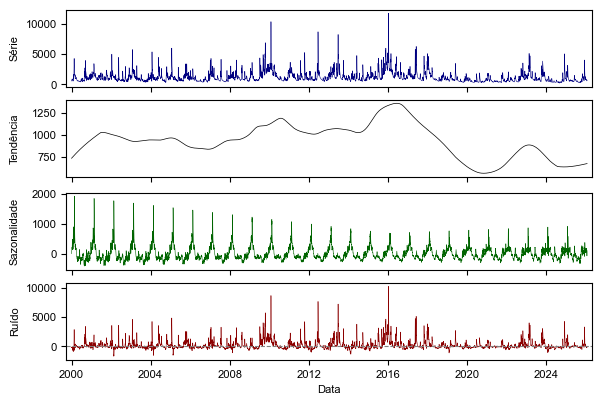

In [7]:

def preparar_serie_diaria(df, nome_reservatorio):
    # Prepara serie diaria de vazao para um reservatorio.
    df_res = df[df['nom_reservatorio'] == nome_reservatorio].copy()
    df_res['din_instante'] = pd.to_datetime(df_res['din_instante'])
    df_res['val_vazaonatural'] = pd.to_numeric(df_res['val_vazaonatural'], errors='coerce')
    df_res = df_res.dropna(subset=['val_vazaonatural'])
    
    if len(df_res) == 0:
        return None
    
    df_res = df_res.set_index('din_instante').sort_index()
    serie = df_res['val_vazaonatural'].copy()
    serie = serie[~serie.index.duplicated(keep='first')]
    serie = serie.asfreq('D')
    if serie.isna().any():
        return None
    return serie


# definir a aparência geral da figura
mpl.rcParams.update({
    'font.family': 'Arial',
    'mathtext.fontset': 'stixsans',
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 9,
})

cm = 1 / 2.54

nome_exemplo = 'CAPIVARA'
serie_ex = preparar_serie_diaria(df, nome_exemplo)

# garantir frequência diária e tratar possíveis falhas
serie_stl = serie_ex.copy().astype(float)
serie_stl = serie_stl.asfreq('D')
serie_stl = serie_stl.interpolate(method='time')

# decomposição STL
stl = STL(serie_stl, period=365, seasonal=61, trend=1095, robust=True)
resultado = stl.fit()

# rótulo, nome da componente, dados, cor, espessura
componentes = [
    ('(a)', 'Série',        serie_stl,           'navy',      0.4),
    ('(b)', 'Tendência',    resultado.trend,     'black',     0.5),
    ('(c)', 'Sazonalidade', resultado.seasonal,  'darkgreen', 0.4),
    ('(d)', 'Ruído',        resultado.resid,     'darkred',   0.4),
]

fig, axes = plt.subplots(
    4, 1,
    figsize=(15 * cm, 10 * cm),
    sharex=True,
    layout='constrained',
)

for ax, (rotulo, ylabel, dados, cor, lw) in zip(axes, componentes):
    ax.plot(dados.index, dados.values, color=cor, linewidth=lw)
    ax.set_ylabel(ylabel)
    ax.margins(x=0.01)

# alinhar os rótulos do eixo y na mesma linha vertical
fig.align_ylabels(axes)

# linha de referência no painel de ruído
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[3].set_xlabel('Data')

fig.savefig("figuras/exemplo_decomposicao.png", dpi=300)